In [9]:
pip install faker

In [10]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

num_students = 250

student_ids = [f'S{i:03d}' for i in range(1, num_students + 1)]
names = [fake.name() for _ in range(num_students)]
genders = np.random.choice(['Male', 'Female'], num_students)
departments = np.random.choice(['CSE', 'IT', 'ECE'], num_students)
years = np.random.choice(['1st', '2nd', '3rd'], num_students)
maths_marks = np.random.randint(40, 100, num_students)
science_marks = np.random.randint(40, 100, num_students)
english_marks = np.random.randint(40, 100, num_students)
attendance = np.random.randint(50, 101, num_students)
internal_marks = np.random.randint(0, 26, num_students)

students_data = pd.DataFrame({
    'Student_ID': student_ids,
    'Name': names,
    'Gender': genders,
    'Department': departments,
    'Year': years,
    'Maths': maths_marks,
    'Science': science_marks,
    'English': english_marks,
    'Attendance (%)': attendance,
    'Internal Marks': internal_marks
})

display(students_data)

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks
0,S001,Jerry Miller,Female,CSE,3rd,91,86,79,72,18
1,S002,Robert Valdez,Female,IT,2nd,68,51,95,97,0
2,S003,Jessica James,Female,ECE,2nd,48,76,89,83,14
3,S004,Bradley Romero,Female,ECE,2nd,78,71,94,85,11
4,S005,Kelly Rodgers,Male,CSE,2nd,68,54,47,69,23
...,...,...,...,...,...,...,...,...,...,...
245,S246,Crystal Harris,Female,CSE,3rd,94,81,95,98,5
246,S247,Lori Buckley,Male,ECE,1st,90,63,53,63,12
247,S248,Misty Kelley,Female,IT,3rd,42,43,73,58,9
248,S249,Joseph Delgado,Female,CSE,2nd,40,59,82,61,16


In [11]:
# Convert the dictionary to a pandas DataFrame
# The 'data' dictionary is assumed to be available from previous cells.
df = pd.DataFrame(data)

print("--- Data Cleaning and Preprocessing ---")

# Check for missing values
print("\nChecking for missing values:")
print(df.isnull().sum())

# Check data types
print("\nChecking data types:")
df.info()

# Display first few rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

--- Data Cleaning and Preprocessing ---

Checking for missing values:
Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64

Checking data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      250 non-null    int64 
 1   Name            250 non-null    object
 2   Gender          250 non-null    object
 3   Department      250 non-null    object
 4   Year            250 non-null    int64 
 5   Maths           250 non-null    int64 
 6   Science         250 non-null    int64 
 7   English         250 non-null    int64 
 8   Attendance      250 non-null    int64 
 9   Internal_Marks  250 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 19.7+ KB

First 5 ro

In [20]:
import numpy as np
import pandas as pd
from faker import Faker

fake = Faker()

data = {
    "Student_ID": np.random.randint(0, 10, 250),
    "Name": [fake.name() for _ in range(250)],
    "Gender": np.random.choice(["Male", "Female"], 250),
    "Department": np.random.choice(["CSE", "IT", "ECE"], 250),
    "Year": np.random.choice([1, 2, 3, 4], 250),
    "Maths": np.random.randint(40, 100, 250),
    "Science": np.random.randint(40, 100, 250),
    "English": np.random.randint(40, 100, 250),
    "Attendance": np.random.randint(50, 100, 250),
    "Internal_Marks": np.random.randint(0, 25, 250)
}

### Relationship Between Variables

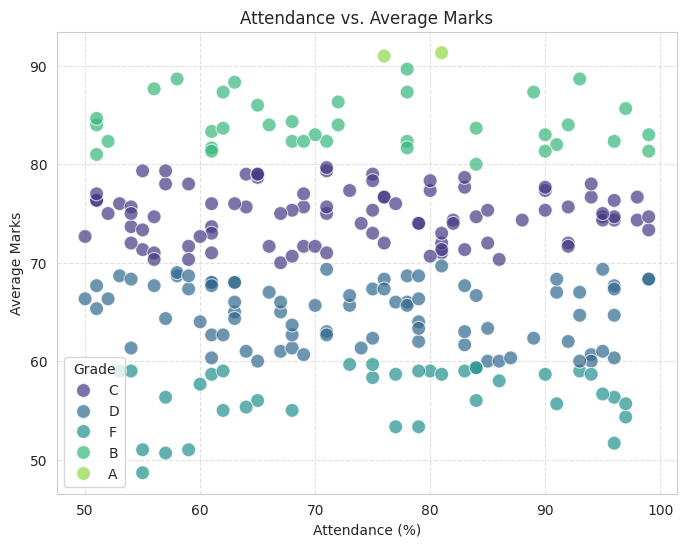

Correlation between Attendance and Average Marks: -0.04


In [21]:
# Relationship: Attendance vs. Marks
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Attendance', y='Average_Marks', data=df, hue='Grade', palette='viridis', s=100, alpha=0.7)
plt.title('Attendance vs. Average Marks')
plt.xlabel('Attendance (%)')
plt.ylabel('Average Marks')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Correlation between Attendance and Average Marks: {df['Attendance'].corr(df['Average_Marks']):.2f}")

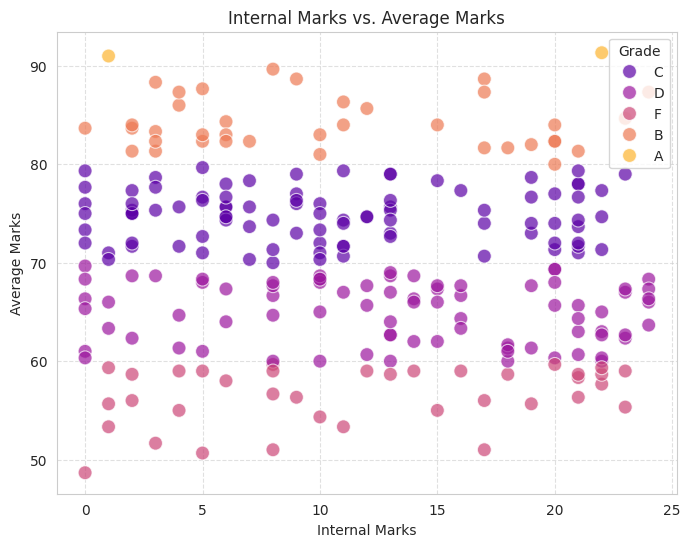

Correlation between Internal Marks and Average Marks: -0.11


In [22]:
# Relationship: Internal marks vs. Final performance (Average Marks)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Internal_Marks', y='Average_Marks', data=df, hue='Grade', palette='plasma', s=100, alpha=0.7)
plt.title('Internal Marks vs. Average Marks')
plt.xlabel('Internal Marks')
plt.ylabel('Average Marks')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Correlation between Internal Marks and Average Marks: {df['Internal_Marks'].corr(df['Average_Marks']):.2f}")

### Group-Based Analysis


--- Department-wise Average Marks ---
Department
CSE    70.670886
IT     70.482759
ECE    70.111111
Name: Average_Marks, dtype: float64


/tmp/ipykernel_5099/632783212.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_performance.index, y=department_performance.values, palette='viridis')


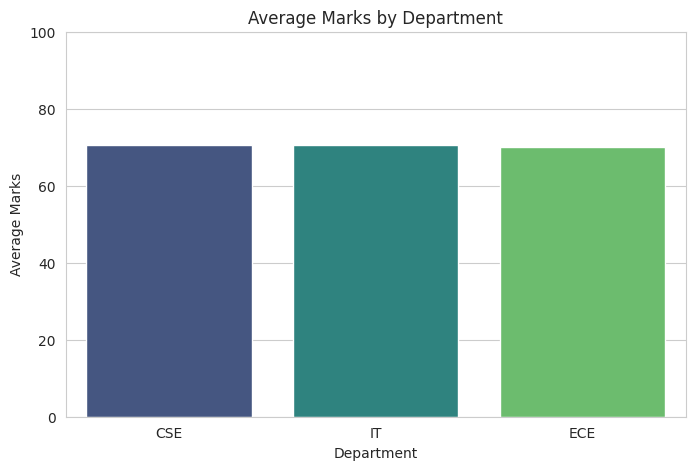

In [23]:
# Department-wise Performance
department_performance = df.groupby('Department')['Average_Marks'].mean().sort_values(ascending=False)
print("\n--- Department-wise Average Marks ---")
print(department_performance)

plt.figure(figsize=(8, 5))
sns.barplot(x=department_performance.index, y=department_performance.values, palette='viridis')
plt.title('Average Marks by Department')
plt.xlabel('Department')
plt.ylabel('Average Marks')
plt.ylim(0, 100) # Set y-axis limits to 0-100 for marks
plt.show()


--- Gender-wise Average Marks ---
Gender
Male      70.600529
Female    70.231183
Name: Average_Marks, dtype: float64


/tmp/ipykernel_5099/248522690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_comparison.index, y=gender_comparison.values, palette='plasma')


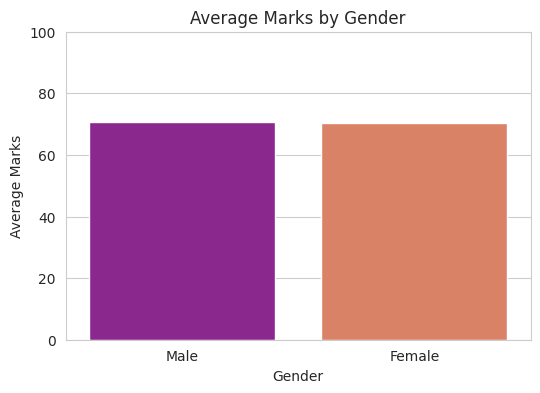

In [24]:
# Gender-wise Comparison
gender_comparison = df.groupby('Gender')['Average_Marks'].mean().sort_values(ascending=False)
print("\n--- Gender-wise Average Marks ---")
print(gender_comparison)

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_comparison.index, y=gender_comparison.values, palette='plasma')
plt.title('Average Marks by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Marks')
plt.ylim(0, 100)
plt.show()


--- Year-wise Average Marks ---
Year
1    67.586207
4    69.763636
3    71.226190
2    72.329218
Name: Average_Marks, dtype: float64


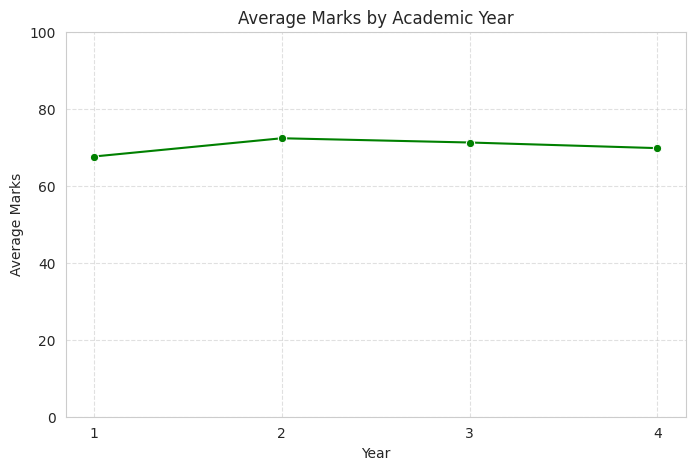

In [25]:
# Year-wise Trends
year_trends = df.groupby('Year')['Average_Marks'].mean().sort_values(ascending=True)
print("\n--- Year-wise Average Marks ---")
print(year_trends)

plt.figure(figsize=(8, 5))
sns.lineplot(x=year_trends.index, y=year_trends.values, marker='o', color='green')
plt.title('Average Marks by Academic Year')
plt.xlabel('Year')
plt.ylabel('Average Marks')
plt.ylim(0, 100)
plt.xticks(year_trends.index) # Ensure all years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Identifying Top and Low Performing Students

In [26]:
# Identify Top Performing Students (Grade 'A')
top_performers = df[df['Grade'] == 'A'].sort_values(by='Average_Marks', ascending=False)
print("\n--- Top Performing Students ---")
display(top_performers[['Name', 'Department', 'Year', 'Total_Marks', 'Average_Marks', 'Grade']].head())

# Identify Low Performing Students (Grade 'F')
low_performers = df[df['Grade'] == 'F'].sort_values(by='Average_Marks', ascending=True)
print("\n--- Low Performing Students ---")
display(low_performers[['Name', 'Department', 'Year', 'Total_Marks', 'Average_Marks', 'Grade']].head())


--- Top Performing Students ---


,Name,Department,Year,Total_Marks,Average_Marks,Grade
135,Lori Diaz,IT,4,274,91.333333,A
240,Barbara Clark,ECE,1,273,91.000000,A



--- Low Performing Students ---


,Name,Department,Year,Total_Marks,Average_Marks,Grade
88,Erica Johnson PhD,IT,4,146,48.666667,F
2,Jeffery Gutierrez,ECE,3,152,50.666667,F
116,Debra Young,IT,2,153,51.000000,F
233,Angela Levine,ECE,4,153,51.000000,F
54,Justin Bowen,IT,2,155,51.666667,F


### Student Performance Analysis

In [27]:
# Calculate Total Marks
df['Total_Marks'] = df['Maths'] + df['Science'] + df['English']

# Calculate Average Marks
df['Average_Marks'] = df['Total_Marks'] / 3

# Define a grading function
def assign_grade(average_marks):
    if average_marks >= 90:
        return 'A'
    elif average_marks >= 80:
        return 'B'
    elif average_marks >= 70:
        return 'C'
    elif average_marks >= 60:
        return 'D'
    else:
        return 'F'

# Apply the grading function to create a 'Grade' column
df['Grade'] = df['Average_Marks'].apply(assign_grade)

print("\n--- Student Performance Metrics ---")
print("DataFrame with Total Marks, Average Marks, and Grade:")
display(df.head())


--- Student Performance Metrics ---
DataFrame with Total Marks, Average Marks, and Grade:


,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total_Marks,Average_Marks,Grade
0,0,Brandi Johnson,Female,IT,2,62,84,77,82,11,223,74.333333,C
1,8,Kenneth Gardner,Female,CSE,2,44,67,86,73,21,197,65.666667,D
2,8,Jeffery Gutierrez,Female,ECE,3,48,54,50,57,5,152,50.666667,F
3,1,Darin Collins,Male,ECE,2,62,96,94,92,20,252,84.000000,B
4,7,Donna Sims,Female,ECE,4,69,48,66,67,0,183,61.000000,D


In [17]:
print("--- Descriptive Statistics ---")

# Descriptive statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(df.describe())

--- Descriptive Statistics ---

Summary statistics for numerical columns:


,Student_ID,Year,Maths,Science,English,Attendance,Internal_Marks,Total_Marks,Average_Marks
count,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,4.856000,2.43200,69.236000,71.464000,70.55200,73.984000,11.560000,211.252000,70.417333
std,2.864277,1.07424,17.092834,17.044965,15.85778,14.210966,7.378358,27.585364,9.195121
min,0.000000,1.00000,40.000000,40.000000,40.00000,50.000000,0.000000,146.000000,48.666667
25%,2.250000,2.00000,53.000000,58.000000,58.00000,61.250000,5.000000,189.000000,63.000000
50%,5.000000,2.00000,69.000000,73.000000,70.00000,74.000000,11.000000,213.000000,71.000000
75%,7.000000,3.00000,83.000000,86.000000,84.00000,84.750000,19.000000,230.000000,76.666667
max,9.000000,4.00000,99.000000,99.000000,99.00000,99.000000,24.000000,274.000000,91.333333


In [18]:
# Calculate mode for relevant columns (describe() doesn't include it)
print("\nMode for numerical columns:")
for col in ['Maths', 'Science', 'English', 'Attendance', 'Internal_Marks']:
    if col in df.columns:
        print(f"  {col}: {df[col].mode().tolist()}")


Mode for numerical columns:
  Maths: [72]
  Science: [76, 95]
  English: [65]
  Attendance: [61]
  Internal_Marks: [21]


### Distribution of Marks

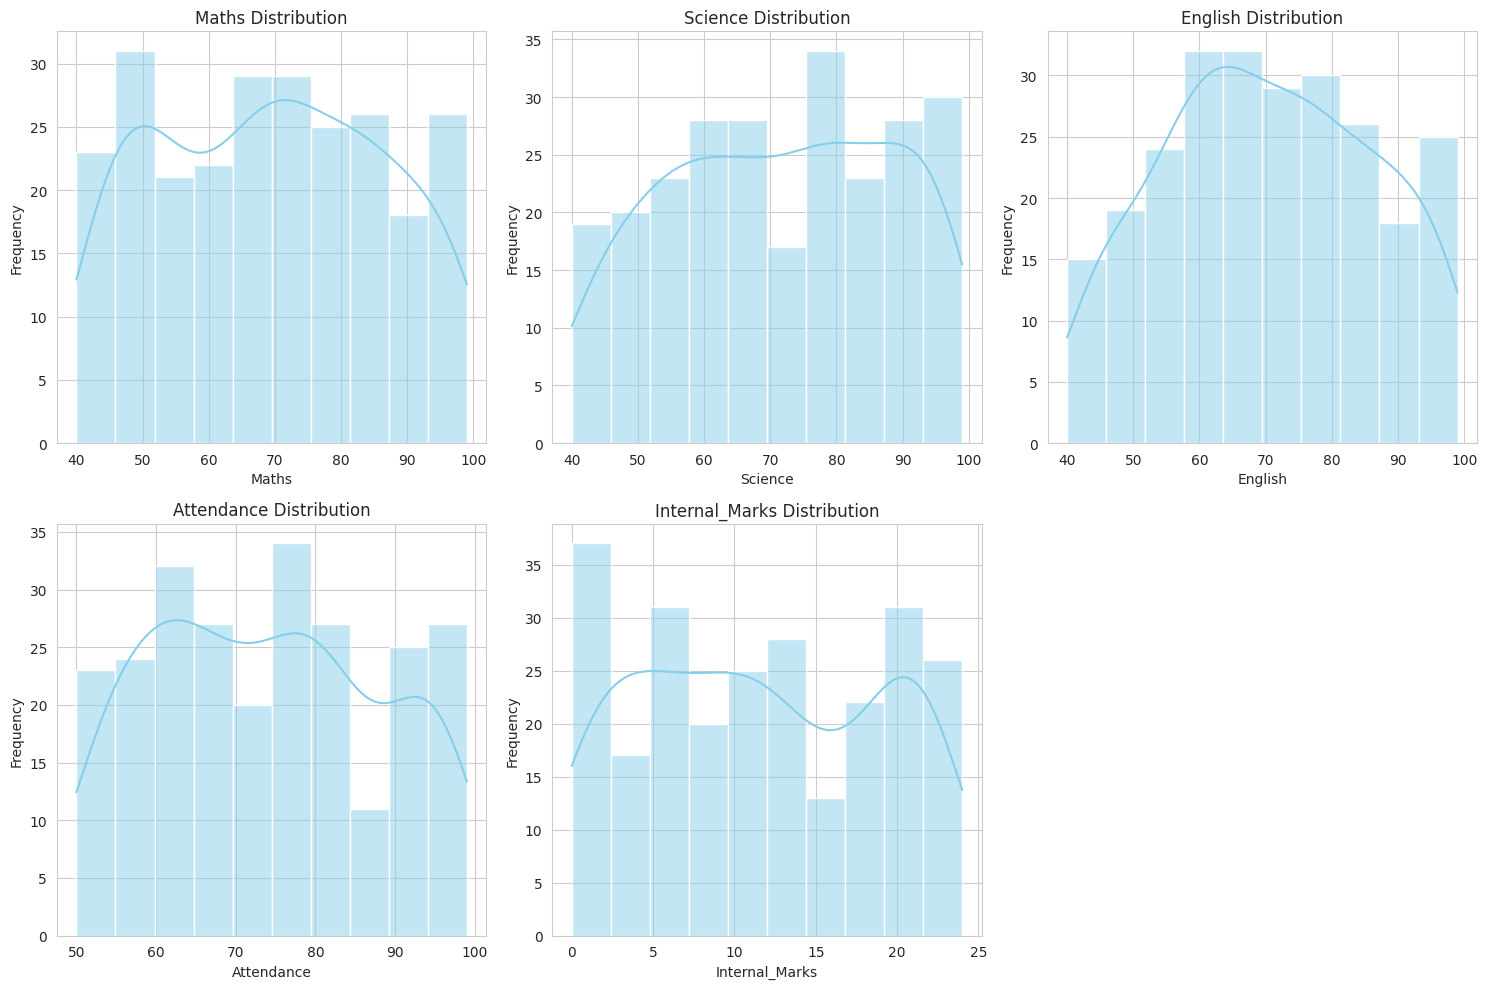

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create histograms for marks distribution
marks_columns = ['Maths', 'Science', 'English', 'Attendance', 'Internal_Marks']

plt.figure(figsize=(15, 10))
for i, col in enumerate(marks_columns):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.histplot(df[col], kde=True, bins=10, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()